<a href="https://colab.research.google.com/github/Haseebtanvir079/Advanced-DataScience/blob/main/CMP7161_lab_S06_Part1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Building a Linear Discriminant Analysis (LDA) Algorithm from Scratch in Python


Linear Discriminant Analysis is a powerful technique for dimensionality reduction and classification. It aims to find a linear combination of features that best separates two or more classes of objects or events. LDA is particularly useful when dealing with multi-class classification problems and can be implemented from scratch using Python.

Before attempting this lab, please make sure to go through the resources provided in the links below. These materials will help you better understand the concepts and prepare you for the tasks in the lab.

https://www.geeksforgeeks.org/ml-linear-discriminant-analysis/

https://sebastianraschka.com/Articles/2014_python_lda.html



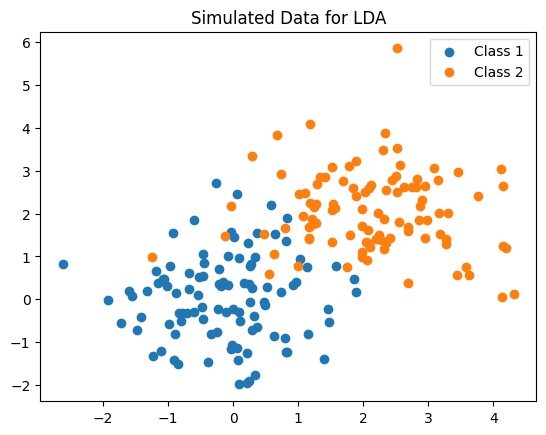

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Simulating two classes of data
np.random.seed(42)
class1 = np.random.multivariate_normal([0, 0], [[1, 0], [0, 1]], 100)
class2 = np.random.multivariate_normal([2, 2], [[1, 0], [0, 1]], 100)

plt.scatter(class1[:, 0], class1[:, 1], label='Class 1')
plt.scatter(class2[:, 0], class2[:, 1], label='Class 2')
plt.legend()
plt.title('Simulated Data for LDA')
plt.show()

Before implementing LDA, we need to prepare our data. This involves splitting the dataset into features (X) and labels (y), as well as separating the data by class. We'll use a simple example with two classes and two features.

In [2]:
# Combine classes and create labels
X = np.vstack((class1, class2))
y = np.hstack((np.zeros(100), np.ones(100)))

# Separate data by class
class1 = X[y == 0]
class2 = X[y == 1]

print("Shape of X:", X.shape)
print("Shape of y:", y.shape)
print("Number of samples in Class 1:", class1.shape[0])
print("Number of samples in Class 2:", class2.shape[0])

Shape of X: (200, 2)
Shape of y: (200,)
Number of samples in Class 1: 100
Number of samples in Class 2: 100


The first step in LDA is to calculate the mean of each class. These means will be used to compute the between-class scatter matrix.


Mean of Class 1: [-0.11556425  0.03402232]
Mean of Class 2: [2.12824872 2.04348765]


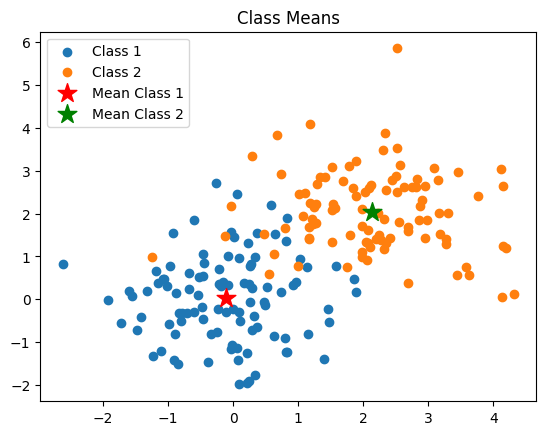

In [3]:
# Calculate class means
mean1 = np.mean(class1, axis=0)
mean2 = np.mean(class2, axis=0)

print("Mean of Class 1:", mean1)
print("Mean of Class 2:", mean2)

# Visualize class means
plt.scatter(class1[:, 0], class1[:, 1], label='Class 1')
plt.scatter(class2[:, 0], class2[:, 1], label='Class 2')
plt.scatter(mean1[0], mean1[1], color='red', s=200, marker='*', label='Mean Class 1')
plt.scatter(mean2[0], mean2[1], color='green', s=200, marker='*', label='Mean Class 2')
plt.legend()
plt.title('Class Means')
plt.show()

The within-class scatter matrix represents the spread of samples around their respective class means. It's calculated by summing the covariance matrices of each class.


In [ ]:
# Compute within-class scatter matrix
S_W = np.zeros((2, 2))
for c, mean in [(class1, mean1), (class2, mean2)]:
    S_c = np.zeros((2, 2))
    for sample in c:
        diff = (sample - mean).reshape(2, 1)
        S_c += np.dot(diff, diff.T)
    S_W += S_c

print("Within-class scatter matrix:")
print(S_W)

The between-class scatter matrix represents the spread of class means around the overall mean. It's calculated using the difference between class means and the overall mean.


In [ ]:
# Compute overall mean
mean_overall = np.mean(X, axis=0)

# Compute between-class scatter matrix
n1, n2 = class1.shape[0], class2.shape[0]
diff1 = (mean1 - mean_overall).reshape(2, 1)
diff2 = (mean2 - mean_overall).reshape(2, 1)
S_B = n1 * np.dot(diff1, diff1.T) + n2 * np.dot(diff2, diff2.T)

print("Between-class scatter matrix:")
print(S_B)

LDA seeks to maximize the ratio of between-class scatter to within-class scatter. This is achieved by solving the generalized eigenvalue problem: S_W^(-1) * S_B * w = λ * w.


In [ ]:
# Solve the generalized eigenvalue problem
eigvals, eigvecs = np.linalg.eig(np.linalg.inv(S_W).dot(S_B))

# Sort eigenvectors by eigenvalues in descending order
idx = eigvals.argsort()[::-1]
eigvals = eigvals[idx]
eigvecs = eigvecs[:, idx]

# Select the eigenvector with the largest eigenvalue
w = eigvecs[:, 0]

print("Largest eigenvalue:", eigvals[0])
print("Corresponding eigenvector:", w)

Once we have the LDA direction (w), we can project our data onto this direction to reduce dimensionality and visualize the separation between classes.


In [ ]:
# Project data onto LDA direction
X_projected = X.dot(w)

# Visualize projected data
plt.scatter(X_projected[y == 0], np.zeros(n1), label='Class 1')
plt.scatter(X_projected[y == 1], np.zeros(n2), label='Class 2')
plt.legend()
plt.title('Data Projected onto LDA Direction')
plt.xlabel('LDA Component')
plt.yticks([])
plt.show()

We can use the LDA direction to classify new data points. The decision boundary is perpendicular to the LDA direction and positioned at the midpoint between the projected class means.


In [ ]:
def lda_classify(x, w, mean1, mean2):
    # Project class means onto LDA direction
    m1 = w.dot(mean1)
    m2 = w.dot(mean2)

    # Compute midpoint
    midpoint = (m1 + m2) / 2

    # Project data point
    projection = w.dot(x)

    # Classify based on which side of the midpoint the projection falls
    return 0 if projection < midpoint else 1

# Test the classifier
test_point = np.array([1, 1])
prediction = lda_classify(test_point, w, mean1, mean2)
print(f"Test point {test_point} classified as Class {prediction}")

# Visualize decision boundary
plt.scatter(class1[:, 0], class1[:, 1], label='Class 1')
plt.scatter(class2[:, 0], class2[:, 1], label='Class 2')
plt.scatter(test_point[0], test_point[1], color='red', s=200, marker='x', label='Test Point')

# Plot decision boundary
boundary_x = np.array([np.min(X[:, 0]), np.max(X[:, 0])])
boundary_y = -(w[0] * boundary_x + (w.dot(mean1 + mean2) / 2)) / w[1]
plt.plot(boundary_x, boundary_y, 'k--', label='Decision Boundary')

plt.legend()
plt.title('LDA Classification')
plt.show()

To assess the performance of our LDA implementation, we can split our data into training and testing sets, train the LDA on the training data, and evaluate its accuracy on the test data.


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train LDA on training data
class1_train = X_train[y_train == 0]
class2_train = X_train[y_train == 1]
mean1_train = np.mean(class1_train, axis=0)
mean2_train = np.mean(class2_train, axis=0)

# Compute scatter matrices and LDA direction using training data
S_W_train = np.zeros((2, 2))
for c, mean in [(class1_train, mean1_train), (class2_train, mean2_train)]:
    S_c = np.zeros((2, 2))
    for sample in c:
        diff = (sample - mean).reshape(2, 1)
        S_c += np.dot(diff, diff.T)
    S_W_train += S_c

mean_overall_train = np.mean(X_train, axis=0)
n1_train, n2_train = class1_train.shape[0], class2_train.shape[0]
diff1_train = (mean1_train - mean_overall_train).reshape(2, 1)
diff2_train = (mean2_train - mean_overall_train).reshape(2, 1)
S_B_train = n1_train * np.dot(diff1_train, diff1_train.T) + n2_train * np.dot(diff2_train, diff2_train.T)

eigvals_train, eigvecs_train = np.linalg.eig(np.linalg.inv(S_W_train).dot(S_B_train))
w_train = eigvecs_train[:, eigvals_train.argsort()[::-1][0]]

# Predict on test data
y_pred = np.array([lda_classify(x, w_train, mean1_train, mean2_train) for x in X_test])

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"LDA Accuracy: {accuracy:.2f}")

Let's apply our LDA implementation to the famous Iris dataset, which contains measurements of three different species of iris flowers.


In [ ]:
from sklearn.datasets import load_iris

# Load Iris dataset
iris = load_iris()
X_iris = iris.data
y_iris = iris.target

# Select two features and two classes for visualization
X_iris_subset = X_iris[:100, [0, 2]]  # Sepal length and petal length
y_iris_subset = y_iris[:100]  # Setosa and Versicolor

# Train LDA on Iris subset
class1_iris = X_iris_subset[y_iris_subset == 0]
class2_iris = X_iris_subset[y_iris_subset == 1]
mean1_iris = np.mean(class1_iris, axis=0)
mean2_iris = np.mean(class2_iris, axis=0)

# Compute LDA direction for Iris data
S_W_iris = np.zeros((2, 2))
for c, mean in [(class1_iris, mean1_iris), (class2_iris, mean2_iris)]:
    S_c = np.zeros((2, 2))
    for sample in c:
        diff = (sample - mean).reshape(2, 1)
        S_c += np.dot(diff, diff.T)
    S_W_iris += S_c

mean_overall_iris = np.mean(X_iris_subset, axis=0)
n1_iris, n2_iris = class1_iris.shape[0], class2_iris.shape[0]
diff1_iris = (mean1_iris - mean_overall_iris).reshape(2, 1)
diff2_iris = (mean2_iris - mean_overall_iris).reshape(2, 1)
S_B_iris = n1_iris * np.dot(diff1_iris, diff1_iris.T) + n2_iris * np.dot(diff2_iris, diff2_iris.T)

eigvals_iris, eigvecs_iris = np.linalg.eig(np.linalg.inv(S_W_iris).dot(S_B_iris))
w_iris = eigvecs_iris[:, eigvals_iris.argsort()[::-1][0]]

# Visualize Iris data and LDA projection
plt.figure(figsize=(12, 5))
plt.subplot(121)
plt.scatter(class1_iris[:, 0], class1_iris[:, 1], label='Setosa')
plt.scatter(class2_iris[:, 0], class2_iris[:, 1], label='Versicolor')
plt.xlabel('Sepal length')
plt.ylabel('Petal length')
plt.legend()
plt.title('Iris Data: Setosa vs Versicolor')

plt.subplot(122)
X_iris_projected = X_iris_subset.dot(w_iris)
plt.scatter(X_iris_projected[y_iris_subset == 0], np.zeros(50), label='Setosa')
plt.scatter(X_iris_projected[y_iris_subset == 1], np.zeros(50), label='Versicolor')
plt.xlabel('LDA Component')
plt.yticks([])
plt.legend()
plt.title('Iris Data Projected onto LDA Direction')

plt.tight_layout()
plt.show()

Let's apply LDA to classify wines based on their chemical properties. We'll use a subset of the Wine Quality dataset from UCI Machine Learning Repository. You can find the dataset on Moodle.


In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Load Wine Quality dataset (assuming you have the CSV file)
wine_data = pd.read_csv('winequality-red.csv', sep=',')

# Prepare data
X_wine = wine_data.drop('quality', axis=1).values
y_wine = (wine_data['quality'] > 5).astype(int).values  # Binary classification: good (1) vs not good (0)

# Standardize features
scaler = StandardScaler()
X_wine_scaled = scaler.fit_transform(X_wine)

# Split data
X_train, X_test, y_train, y_test = train_test_split(X_wine_scaled, y_wine, test_size=0.2, random_state=42)

# Implement LDA (simplified for demonstration)
def fit_lda(X, y):
    class_means = [X[y == c].mean(axis=0) for c in [0, 1]]
    overall_mean = X.mean(axis=0)

    S_W = np.cov(X[y == 0].T) + np.cov(X[y == 1].T)
    S_B = np.outer(class_means[1] - class_means[0], class_means[1] - class_means[0])

    eigvals, eigvecs = np.linalg.eig(np.linalg.inv(S_W).dot(S_B))
    return eigvecs[:, eigvals.argsort()[::-1][0]]

# Fit LDA and transform data
w_wine = fit_lda(X_train, y_train)
X_train_lda = X_train.dot(w_wine)
X_test_lda = X_test.dot(w_wine)

# Classify using simple threshold
threshold = X_train_lda.mean()
y_pred = (X_test_lda > threshold).astype(int)

# Calculate accuracy
accuracy = (y_pred == y_test).mean()
print(f"LDA Accuracy on Wine Quality dataset: {accuracy:.2f}")

Let's visualize the LDA projection for the Wine Quality dataset to see how well it separates the classes.



In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

# Plot LDA projection
plt.subplot(121)
plt.hist(X_train_lda[y_train == 0], bins=20, alpha=0.5, label='Not Good')
plt.hist(X_train_lda[y_train == 1], bins=20, alpha=0.5, label='Good')
plt.axvline(threshold, color='r', linestyle='--', label='Decision Boundary')
plt.xlabel('LDA Component')
plt.ylabel('Frequency')
plt.legend()
plt.title('LDA Projection of Wine Quality Data')

# Plot feature importance
plt.subplot(122)
feature_importance = abs(w_wine)
feature_names = wine_data.columns[:-1]
sorted_idx = feature_importance.argsort()
pos = np.arange(sorted_idx.shape[0]) + .5
plt.barh(pos, feature_importance[sorted_idx], align='center')
plt.yticks(pos, feature_names[sorted_idx])
plt.xlabel('Absolute Weight')
plt.title('LDA Feature Importance')

plt.tight_layout()
plt.show()

Dimensionality reduction: LDA can project high-dimensional data onto a lower-dimensional space while preserving class separability.

Interpretability: The LDA components provide insight into which features are most important for classification.

Efficiency: LDA can be computationally efficient, especially for large datasets.